# Loss Landscape Visualization

Sweeps all pairs of trainable AdEx parameters over a grid, simulates at each point,
and plots the loss surfaces as:
1. A lower-triangle grid of 2D contour plots (21 pairs)
2. Individual 3D surface plots with contour projection (Ackley-style)

In [59]:
import copy
import logging
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config

from ADoptEX.core import simulate_jaxley
from ADoptEX.core.data import TraceData, crop_to_stim_window, detect_spikes, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    GuarinoFeatures,
    GuarinoLossConfig,
    VanRossumLossConfig,
    extract_experimental_features,
    guarino_loss,
    make_guarino_loss_fn,
    make_van_rossum_loss_fn,
    spike_train_from_voltage,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training import TrainingResult
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

## 1. Load & Crop Data

In [60]:
initial_params = dict(NAUD_PARAMETERS["tonic"])
initial_params["v_threshold"] = 0.0
print(initial_params)

current_pA = initial_params["I"]

t_max_ms = 100
dt_ms = 0.025
T = np.linspace(0, t_max_ms, int(t_max_ms / dt_ms))

sim_init = simulate_jaxley(
    params=initial_params,
    stim_current_pA=current_pA,
    stim_duration_ms=100,
    dt_ms=dt_ms,
    t_max_ms=t_max_ms,
    stim_delay_ms=0.0,
    use_surrogate=False,
)

T = np.append(T, T[-1] + dt_ms)
print(len(T))

{'C_m': 200.0, 'g_L': 10.0, 'E_L': -70.0, 'v_T': -50.0, 'delta_T': 2.0, 'v_reset': -58.0, 'v_threshold': 0.0, 'tau_w': 30.0, 'a': 2.0, 'b': 0.0, 'I': 500.0}
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
4001


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:82: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


## 2. Setup Cell & Loss Function

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Initial loss: 100000000.0000
Trainable parameters (8): ['capacitance', 'g_L', 'E_L', 'v_T', 'v_reset', 'tau_w', 'a', 'b']
Initial parameters: {'C_m': 2

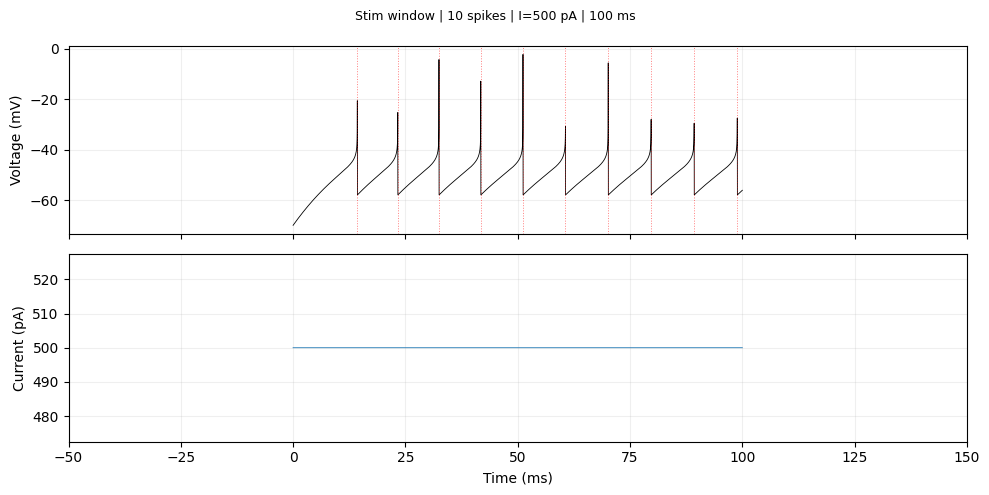

In [61]:
from ADoptEX.loss import (
    extract_experimental_features,
    GuarinoLossConfig,
    make_guarino_loss_fn,
)

training_config = TrainingConfig(
    optimizer="adam",
    learning_rate=0.01,
    n_epochs=1,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
)

trace_stim_window_plot(TraceData(
    T,
    sim_init.voltage,
    np.full(len(T), initial_params["I"]),
    dt_ms,
    sim_init.spike_times,
    0,
    len(T),
    initial_params["I"]))

cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=np.full(len(T), initial_params["I"]),
    dt_ms=dt_ms,
    config=training_config,
)

target_voltage = jnp.array(sim_init.voltage)
stim_end_index = t_max_ms  # already 0-based in cropped trace

# loss_name = 'MSE'
# loss_fn = make_mse_loss_fn(
#     cell=cell,
#     data_stimuli=data_stimuli,
#     t_max=t_max,
#     dt_ms=data.dt_ms,
#     exp_voltage=target_voltage,
#     stim_end_index=data.stim_end_idx,
#     loss_config=MSELossConfig(normalize=False, clamp_threshold=None),
# )


# Extract target features from experimental trace (hard spike detection)
exp_features = extract_experimental_features(
    voltage_trace=target_voltage,
    dt_ms=dt_ms,
    stim_duration_ms=stim_end_index,
    stim_end_index=len(sim_init.voltage),
)

loss_name = "Guarino"
loss_fn = make_guarino_loss_fn(
    cell=cell,
    data_stimuli=data_stimuli,
    t_max=t_max,
    dt_ms=dt_ms,
    exp_features=exp_features,
    stim_duration_ms=t_max_ms,
    stim_end_index=len(sim_init.voltage),
    loss_config=GuarinoLossConfig(
        weight_spike_count=0.0,
    ),
)


# Build param name -> index mapping
param_index = {}
for i, p in enumerate(trainable_params):
    for k in p:
        param_index[k.replace("AdEx_", "")] = i

PARAM_NAMES = list(param_index.keys())
N_PARAMS = len(PARAM_NAMES)

loss_init = loss_fn(trainable_params)
print(f"Initial loss: {float(loss_init):.4f}")
print(f"Trainable parameters ({N_PARAMS}): {PARAM_NAMES}")
print(f"Initial parameters: {initial_params}")


## 3. Sweep All Parameter Pairs

For each of the C(7,2) = 21 pairs, build a grid over their PARAM_BOUNDS and
evaluate the loss. Non-swept parameters stay at their default values.

In [62]:
# Storage for all grids
GRID_SIZE = 20  # 30x30;

t_start = time.time()

px, py = "g_L", "E_L"
bx, by = PARAM_BOUNDS[px], PARAM_BOUNDS[py]

x_vals = np.linspace(bx.min, bx.max, GRID_SIZE)
y_vals = np.linspace(by.min, by.max, GRID_SIZE)
X, Y = np.meshgrid(x_vals, y_vals)
Z = np.full((GRID_SIZE, GRID_SIZE), np.nan)

ix, iy = param_index[px], param_index[py]

eta = np.nan

for r in range(GRID_SIZE):
    print('[' + '#' * r + ' ' * (GRID_SIZE - r) + f'], ETA: {eta:.0f}s', end='\r')
    for c in range(GRID_SIZE):
        params_rc = copy.deepcopy(trainable_params)
        params_rc[ix] = {f"AdEx_{px}": jnp.array([X[r, c]])}
        params_rc[iy] = {f"AdEx_{py}": jnp.array([Y[r, c]])}
        try:
            Z[r, c] = float(loss_fn(params_rc))
        except Exception:
            Z[r, c] = np.nan
    
    eta = ((time.time() - t_start) / (r+1)) * (GRID_SIZE - (r + 1))

print('[' + '#' * GRID_SIZE + ']               ' )
print(f"\nTotal time: {time.time() - t_start:.0f}s")

[####################]               

Total time: 50s


## 4. Triangle Grid — All Pairs (2D Contour)

Lower-triangle matrix: row = second parameter, column = first parameter.
Each cell shows a filled contour of the loss landscape for that pair.

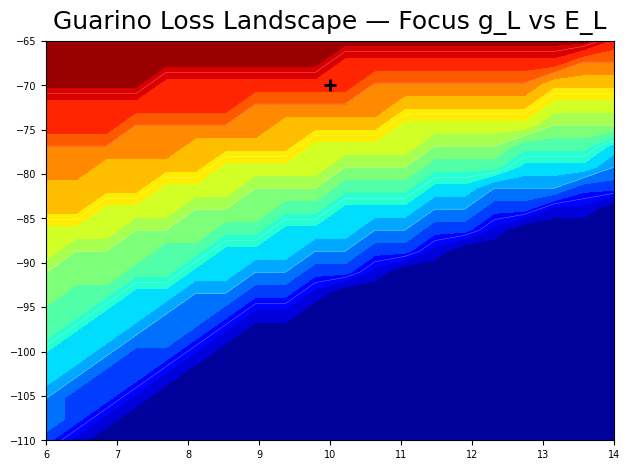

Saved to guarino_loss_landscape_focus_g_L_E_L.pdf


In [65]:
import matplotlib.pyplot as plt
from matplotlib import cm
Z_plot = np.clip(Z, np.nanmin(Z), np.nanpercentile(Z, 95))
plt.contourf(X, Y, Z_plot, levels=20, cmap=cm.jet)
plt.contour(
    X, Y, Z_plot, levels=8, colors="white", linewidths=0.3, alpha=0.5
)

def map_name_to_trainable_params(s):
    if s == "capacitance":
        return "C_m"
    return s

# Mark default params
plt.plot(
    initial_params[map_name_to_trainable_params(px)],
    initial_params[map_name_to_trainable_params(py)],
    "k+",
        markersize=8,
        markeredgewidth=2,
    )

plt.tick_params(labelsize=7)

# Diagonal labels

plt.title(f"{loss_name} Loss Landscape — Focus {px} vs {py}", fontsize=18, y=1.01)
plt.tight_layout()

filename = f"{loss_name.lower()}_loss_landscape_focus_{px}_{py}.pdf"
plt.savefig(
    filename, dpi=150, bbox_inches="tight"
)
plt.show()

print(f"Saved to {filename}")

## 5. Individual 3D Surface Plots

Ackley-style 3D surface with contour projection for each parameter pair.

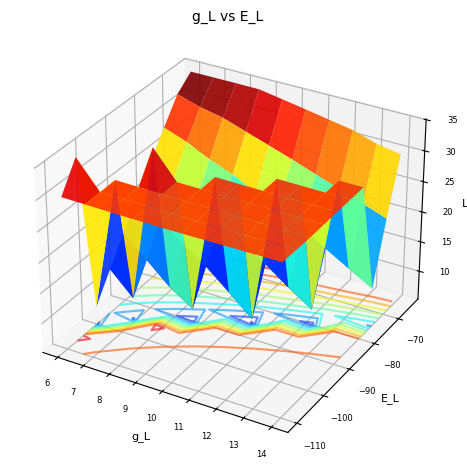

Saved to guarino_loss_landscape_3d_focus.png


In [35]:
ax = plt.subplot(projection="3d")

surf = ax.plot_surface(
    X,
    Y,
    Z_plot,
    cmap=cm.jet,
    edgecolor="none",
    alpha=0.9,
    rstride=1,
    cstride=1,
)

# Contour projection on the floor
z_floor = ax.get_zlim()[0]
ax.contour(
    X,
    Y,
    Z_plot,
    levels=10,
    zdir="z",
    offset=z_floor,
    cmap=cm.jet,
    alpha=0.6,
)

ax.set_xlabel(px, fontsize=8, labelpad=2)
ax.set_ylabel(py, fontsize=8, labelpad=2)
ax.set_zlabel("Loss", fontsize=8, labelpad=2)
ax.set_title(f"{px} vs {py}", fontsize=10, pad=2)
ax.tick_params(labelsize=6)
ax.view_init(elev=30, azim=-60)

plt.tight_layout()
plt.savefig(
    f"{loss_name.lower()}_loss_landscape_3d_focus.pdf", dpi=150, bbox_inches="tight"
)
plt.show()
print(f"Saved to {loss_name.lower()}_loss_landscape_3d_focus.png")